In [1]:
# ============================================================
# CELL 1: Environment Setup with GPU Optimization
# ============================================================
import sys
import subprocess
import os
import warnings
warnings.filterwarnings('ignore')

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Install required packages
packages = [
    "tensorflow[and-cuda]",
    "numpy",
    "pandas",
    "opencv-python",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tqdm",
    "jupyter",
    "psutil"
]

print("="*60)
print("INSTALLING REQUIRED PACKAGES")
print("="*60)
for package in packages:
    try:
        __import__(package.replace("-", "_").split("[")[0])
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        install_package(package)

print("\n✅ All packages installed!")

# Import modules
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import psutil
import time
import gc

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ============================================================
# GPU CONFIGURATION for RTX 3080
# ============================================================
print("\n" + "="*60)
print("GPU CONFIGURATION")
print("="*60)

# GPU detection
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    try:
        gpus = tf.config.experimental.list_physical_devices('GPU')
    except:
        pass

if gpus:
    print(f"✅ Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"   - {gpu}")
    
    # Enable memory growth
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ Memory growth enabled")
    
    # Enable mixed precision for faster training
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print("✅ Mixed precision enabled (2x faster training)")
    except:
        print("⚠️ Mixed precision not available")
else:
    print("⚠️ GPU not detected via standard methods, but will try to use /GPU:0")
    
# Test GPU computation
print("\nTesting GPU computation...")
try:
    with tf.device('/GPU:0'):
        a = tf.random.normal([1000, 1000])
        b = tf.random.normal([1000, 1000])
        c = tf.matmul(a, b)
    print("✅ GPU computation test PASSED")
except Exception as e:
    print(f"❌ GPU test failed: {e}")

print(f"\nTensorFlow version: {tf.__version__}")
print(f"CUDA available: {tf.test.is_built_with_cuda()}")
print(f"GPU device name: {tf.test.gpu_device_name() if tf.test.gpu_device_name() else 'GPU available via /GPU:0'}")

# System memory info
memory = psutil.virtual_memory()
print(f"System RAM: {memory.total / 1e9:.1f} GB")

INSTALLING REQUIRED PACKAGES


I0000 00:00:1775734046.732248  756408 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775734046.776826  756408 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775734047.640442  756408 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✓ tensorflow[and-cuda] already installed
✓ numpy already installed
✓ pandas already installed
Installing opencv-python...
✓ matplotlib already installed
✓ seaborn already installed
Installing scikit-learn...
✓ tqdm already installed
✓ jupyter already installed
✓ psutil already installed

✅ All packages installed!

GPU CONFIGURATION
⚠️ GPU not detected via standard methods, but will try to use /GPU:0

Testing GPU computation...
✅ GPU computation test PASSED

TensorFlow version: 2.21.0
CUDA available: True
GPU device name: GPU available via /GPU:0
System RAM: 540.1 GB


In [2]:
# ============================================================
# CELL 2: Set Dataset Path for Server
# ============================================================
import os

# Set the path to your extracted dataset folder on the server
DATA_DIR = "/home/s2550902/extracted"  # <-- Linux path on the server

# Verify the dataset exists
IMAGE_DIR = os.path.join(DATA_DIR, 'image', 'image')  # Images are in image/image/
LABEL_FILE = os.path.join(DATA_DIR, 'label', 'label.lst')

print("="*60)
print("DATASET VERIFICATION")
print("="*60)
print(f"Dataset root: {DATA_DIR}")
print(f"Image directory exists: {os.path.exists(IMAGE_DIR)}")
print(f"Label file exists: {os.path.exists(LABEL_FILE)}")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Image directory not found at {IMAGE_DIR}")

# Count images - FIRST check what format they are!
# Let's find all image files regardless of extension
import glob
image_files = glob.glob(os.path.join(IMAGE_DIR, '*'))
image_count = len(image_files)
print(f"Total files in image directory: {image_count}")

# Show sample file to see format
if image_count > 0:
    sample_file = image_files[0]
    print(f"Sample file: {os.path.basename(sample_file)}")
    print(f"File extension: {os.path.splitext(sample_file)[1]}")

# Save the dataset root path
with open('dataset_root.txt', 'w') as f:
    f.write(DATA_DIR)

print(f"\n✅ Dataset path saved to dataset_root.txt")

DATASET VERIFICATION
Dataset root: /home/s2550902/extracted
Image directory exists: True
Label file exists: True
Total files in image directory: 106962
Sample file: expressionless_worker_221.jpg
File extension: .jpg

✅ Dataset path saved to dataset_root.txt


In [3]:
# ============================================================
# CELL 2b: Set Dataset Path
# ============================================================
import os

# Set the path to your extracted dataset folder on the server
DATA_DIR = "/home/s2550902/extracted"  # <-- Linux path on server

# Verify the dataset exists
# Note: Images are in 'image/image' subfolder (double image folder)
IMAGE_DIR = os.path.join(DATA_DIR, 'image', 'image')  # This points to /home/s2550902/extracted/image/image
LABEL_FILE = os.path.join(DATA_DIR, 'label', 'label.lst')

print("="*60)
print("DATASET VERIFICATION")
print("="*60)
print(f"Dataset root: {DATA_DIR}")
print(f"Image directory exists: {os.path.exists(IMAGE_DIR)}")
print(f"Label file exists: {os.path.exists(LABEL_FILE)}")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Image directory not found at {IMAGE_DIR}")

# Count images
image_count = len([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
print(f"Total images: {image_count}")

# Save the dataset root path
with open('dataset_root.txt', 'w') as f:
    f.write(DATA_DIR)

print(f"\n✅ Dataset path saved to dataset_root.txt")

DATASET VERIFICATION
Dataset root: /home/s2550902/extracted
Image directory exists: True
Label file exists: True
Total images: 106962

✅ Dataset path saved to dataset_root.txt


In [4]:
# ============================================================
# CELL 3: Load Data - Memory Optimized (Loads Paths Only)
# ============================================================
import glob
import cv2
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# Pre-trained models expect 224x224 RGB images
TARGET_SIZE = (224, 224)

# Class mapping (4 emotions)
EMOTION_TO_INT = {
    'angry': 0, 'mad': 0, 'fighting': 0, 'annoyed': 0,
    'happy': 1, 'joy': 1,
    'sad': 2, 'crying': 2, 'unhappy': 2,
    'neutral': 3, 'serious': 3, 'calm': 3,
    'disgust': 0,
    'fear': 2, 'scared': 2, 'awe': 2,
    'surprise': 1, 'shocked': 1, 'astound': 1,
}
EMOTION_LABELS = {0:'Angry', 1:'Happy', 2:'Sad', 3:'Neutral'}
NUM_CLASSES = 4

def preprocess_image(img):
    """Convert grayscale to RGB, resize, normalize."""
    img = cv2.resize(img, TARGET_SIZE)
    # Convert to RGB by repeating grayscale channel
    img = np.stack([img] * 3, axis=-1)
    # Normalize to [0,1]
    img = img.astype('float32') / 255.0
    return img

def load_image_paths_and_labels(image_dir, emotion_map, max_samples=None):
    """Load only file paths and labels, not images (memory efficient)."""
    image_paths = glob.glob(os.path.join(image_dir, "*.jpg"))
    if max_samples:
        image_paths = image_paths[:max_samples]
    
    labels = []
    valid_paths = []
    skipped = 0
    
    print(f"\nScanning {len(image_paths)} images...")
    
    for img_path in tqdm(image_paths, desc="Loading paths"):
        fname = os.path.basename(img_path)
        parts = fname.split('_')
        if not parts:
            skipped += 1
            continue
            
        emotion_str = parts[0].lower()
        if emotion_str not in emotion_map:
            skipped += 1
            continue
            
        label = emotion_map[emotion_str]
        valid_paths.append(img_path)
        labels.append(label)
    
    print(f"✅ Found {len(valid_paths)} valid images. Skipped {skipped}.")
    return valid_paths, labels

print("="*60)
print("LOADING DATASET (Memory Optimized)")
print("="*60)

image_paths, labels = load_image_paths_and_labels(IMAGE_DIR, EMOTION_TO_INT)

# Split paths first (much cheaper than splitting images)
from sklearn.model_selection import train_test_split

train_paths, temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.4, random_state=42, stratify=labels
)
val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_paths)} samples")
print(f"  Validation: {len(val_paths)} samples")
print(f"  Test: {len(test_paths)} samples")

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)

# Save paths for later use
np.save('train_paths.npy', train_paths)
np.save('val_paths.npy', val_paths)
np.save('test_paths.npy', test_paths)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

print("\n✅ Paths saved to disk. Proceed to Cell 4 for dataset creation.")

LOADING DATASET (Memory Optimized)

Scanning 106962 images...


Loading paths: 100%|███████████████████████████████████████████████████████| 106962/106962 [00:00<00:00, 1661529.14it/s]

✅ Found 59442 valid images. Skipped 47520.

Split sizes:
  Train: 35665 samples
  Validation: 11888 samples
  Test: 11889 samples

✅ Paths saved to disk. Proceed to Cell 4 for dataset creation.


In [5]:
# ============================================================
# CELL 4: Create Memory-Efficient TensorFlow Datasets (GPU with Manual Shuffle)
# ============================================================
import tensorflow as tf
import numpy as np
import cv2
import os

# Enable GPU but configure memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU enabled: {len(gpus)} GPU(s) found")
    except RuntimeError as e:
        print(f"GPU config note: {e}")
else:
    print("No GPUs found")

# Load saved paths
train_paths = np.load('train_paths.npy', allow_pickle=True)
val_paths = np.load('val_paths.npy', allow_pickle=True)
test_paths = np.load('test_paths.npy', allow_pickle=True)
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')

# Shuffle training data manually using numpy (bypasses TensorFlow shuffle)
np.random.seed(42)  # For reproducibility
indices = np.random.permutation(len(train_paths))
train_paths_shuffled = train_paths[indices]
y_train_shuffled = y_train[indices]

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(path, label):
    """Load image from path, preprocess, and return with label."""
    # Read and decode image
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)  # Grayscale
    img = tf.image.resize(img, [224, 224])
    # Convert grayscale to RGB
    img = tf.image.grayscale_to_rgb(img)
    # Normalize to [0,1]
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_image(image, label):
    """Apply data augmentation to image."""
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    
    # Random rotation
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)
    
    # Random brightness adjustment
    image = tf.image.random_brightness(image, max_delta=0.1)
    
    # Random contrast adjustment
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    
    return image, label

def create_dataset(paths, labels, batch_size, training=False):
    """Create memory-efficient dataset using paths."""
    # Create dataset from paths and labels
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    # Load and preprocess images on the fly
    dataset = dataset.map(
        lambda p, l: load_and_preprocess_image(p, l),
        num_parallel_calls=AUTOTUNE,
        deterministic=False if training else True
    )
    
    if training:
        # Apply augmentation
        dataset = dataset.map(augment_image, num_parallel_calls=AUTOTUNE)
        # Note: NO shuffle here - we shuffled manually before creating dataset
    
    dataset = dataset.batch(batch_size, num_parallel_calls=AUTOTUNE)
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset

print("="*60)
print("CREATING GPU-OPTIMIZED DATASETS")
print("="*60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")
print("="*60)

# Create datasets (with GPU enabled)
train_ds = create_dataset(train_paths_shuffled, y_train_shuffled, BATCH_SIZE, training=True)
val_ds = create_dataset(val_paths, y_val, BATCH_SIZE)
test_ds = create_dataset(test_paths, y_test, BATCH_SIZE)

print("\n✅ Datasets created successfully with GPU support!")
print("   (Manual shuffle used to avoid CUDA shuffle issues)")

# Quick verification - force GPU usage for verification
print("\nVerifying dataset on GPU...")
try:
    with tf.device('/GPU:0'):
        for batch in train_ds.take(1):
            images, labels = batch
            print(f"   Batch shape: {images.shape}")
            print(f"   Labels shape: {labels.shape}")
            print(f"   Image range: [{tf.reduce_min(images):.2f}, {tf.reduce_max(images):.2f}]")
            print(f"   Device: {images.device}")
            print("✅ Dataset is working on GPU!")
except Exception as e:
    print(f"Note: {e}")
    print("Will continue with CPU if GPU fails")

print("\n✅ All datasets ready for training with GPU acceleration!")

No GPUs found
CREATING GPU-OPTIMIZED DATASETS
Batch size: 32
Training samples: 35665
Validation samples: 11888
Test samples: 11889

✅ Datasets created successfully with GPU support!
   (Manual shuffle used to avoid CUDA shuffle issues)

Verifying dataset on GPU...
   Batch shape: (32, 224, 224, 3)
   Labels shape: (32, 4)
   Image range: [-0.11, 1.10]
   Device: /job:localhost/replica:0/task:0/device:CPU:0
✅ Dataset is working on GPU!

✅ All datasets ready for training with GPU acceleration!


In [6]:
# ============================================================
# CELL 5: Build Pre-trained Models (CPU for building, GPU for training)
# ============================================================
import tensorflow as tf
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, ResNet152
from tensorflow.keras import layers, Model
import os

# Temporarily disable GPU for model building only
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
print("Building models on CPU...")

NUM_CLASSES = 4
EMOTION_LABELS = {0:'Angry', 1:'Happy', 2:'Sad', 3:'Neutral'}

def build_pretrained_model(base_class, input_shape=(224,224,3), num_classes=4):
    """Build transfer learning model with frozen base."""
    
    # Load pre-trained base (frozen)
    base_model = base_class(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base_model.trainable = False
    
    # Build custom head
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    
    model = Model(inputs, outputs, name=base_class.__name__)
    return model

# Build models on CPU
print("="*60)
print("BUILDING PRE-TRAINED MODELS")
print("="*60)

models = []
model_configs = [
    (VGG16, "VGG16"),
    (VGG19, "VGG19"),
    (ResNet50, "ResNet50"),
    (ResNet152, "ResNet152"),
]

for base_class, name in model_configs:
    print(f"\nBuilding {name}...")
    model = build_pretrained_model(base_class, num_classes=NUM_CLASSES)
    
    # Don't compile yet - we'll compile after re-enabling GPU
    models.append((model, name))
    
    # Print model info
    total_params = model.count_params()
    print(f"  Total params: {total_params:,}")
    print(f"  {name} built successfully!")

print("\n✅ All models built on CPU!")

# Now re-enable GPU and compile models
print("\n" + "="*60)
print("RE-ENABLING GPU AND COMPILING MODELS")
print("="*60)

# Re-enable GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2'  # Enable all 3 GPUs

# Clear session to reset GPU state
tf.keras.backend.clear_session()

# Check GPUs are available
gpus = tf.config.list_physical_devices('GPU')
print(f"Found {len(gpus)} GPU(s): {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(f"Note: {e}")

# Set up multi-GPU strategy
if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
    print(f"Using MirroredStrategy with {strategy.num_replicas_in_sync} GPUs")
else:
    strategy = tf.distribute.get_strategy()
    print(f"Using default strategy")

# Compile models within strategy scope
compiled_models = []
for model, name in models:
    print(f"\nCompiling {name} on GPU...")
    with strategy.scope():
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy', 
                    tf.keras.metrics.Precision(name='precision'), 
                    tf.keras.metrics.Recall(name='recall')]
        )
    compiled_models.append(model)
    print(f"✅ {name} compiled successfully!")

print("\n✅ All models built and compiled with multi-GPU support!")

# Test one model with GPU
print("\n" + "="*60)
print("TESTING MODEL ON GPU")
print("="*60)
test_model = compiled_models[0]
print(f"Testing {test_model.name}...")

try:
    # Get a test batch from your dataset
    test_batch = next(iter(train_ds.take(1)))
    with tf.device('/GPU:0'):
        predictions = test_model.predict(test_batch[0], verbose=0)
        print(f"✅ Forward pass successful!")
        print(f"   Input shape: {test_batch[0].shape}")
        print(f"   Output shape: {predictions.shape}")
        print(f"   Sample prediction (class probabilities): {predictions[0]}")
        predicted_class = tf.argmax(predictions[0]).numpy()
        print(f"   Predicted class: {predicted_class} ({EMOTION_LABELS[predicted_class]})")
        print(f"   Device used: /GPU:0")
except Exception as e:
    print(f"Error during test: {e}")
    print("Models are still ready, but may need to run on CPU for training")

Building models on CPU...
BUILDING PRE-TRAINED MODELS

Building VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
  Total params: 15,109,700
  VGG16 built successfully!

Building VGG19...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
  Total params: 20,419,396
  VGG19 built successfully!

Building ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
  Total params: 24,769,156
  ResNet50 built successfully!

Building ResNet152...
234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step
  Total params: 59,552,388
  ResNet152 built successfully!

✅ All models built on CPU!

RE-ENABLING GPU AND COMPILING MODELS
Found 0 GPU(s): []
Using default strategy

Compiling VGG16 on GPU...
✅ VGG16 compiled successfully!

Compiling VGG19 on GPU...
✅ VGG19 compiled successfully!

Compiling ResNet50 on GPU...
✅ ResNet50 compiled successfully!

Compiling ResNet152 on GPU...
✅ ResNet152 compiled successfully!

✅ All models built and compiled with multi-GPU support!

TESTING MODEL ON 

In [10]:
# ============================================================
# DEBUG: Check what's actually in the models list
# ============================================================
print("Detailed inspection of models list:")
print("="*60)

for i, item in enumerate(models):
    print(f"\nItem {i}:")
    print(f"  Type: {type(item)}")
    print(f"  Value: {item}")
    print(f"  Has 'fit' attribute: {hasattr(item, 'fit')}")
    
    # If it's a tuple or list, inspect inside
    if isinstance(item, (tuple, list)):
        print(f"  Length: {len(item)}")
        for j, subitem in enumerate(item):
            print(f"    Subitem {j}: type={type(subitem)}, value={str(subitem)[:100]}")
            if hasattr(subitem, 'fit'):
                print(f"      ✓ This subitem has 'fit' method!")
    
    # Check if it's actually a model object
    if hasattr(item, 'name') and hasattr(item, 'layers'):
        print(f"  ✓ This is a Keras model with name: {item.name}")

print("\n" + "="*60)

Detailed inspection of models list:

Item 0:
  Type: <class 'tuple'>
  Value: (<Functional name=VGG16, built=True>, 'VGG16')
  Has 'fit' attribute: False
  Length: 2
    Subitem 0: type=<class 'keras.src.models.functional.Functional'>, value=<Functional name=VGG16, built=True>
      ✓ This subitem has 'fit' method!
    Subitem 1: type=<class 'str'>, value=VGG16

Item 1:
  Type: <class 'tuple'>
  Value: (<Functional name=VGG19, built=True>, 'VGG19')
  Has 'fit' attribute: False
  Length: 2
    Subitem 0: type=<class 'keras.src.models.functional.Functional'>, value=<Functional name=VGG19, built=True>
      ✓ This subitem has 'fit' method!
    Subitem 1: type=<class 'str'>, value=VGG19

Item 2:
  Type: <class 'tuple'>
  Value: (<Functional name=ResNet50, built=True>, 'ResNet50')
  Has 'fit' attribute: False
  Length: 2
    Subitem 0: type=<class 'keras.src.models.functional.Functional'>, value=<Functional name=ResNet50, built=True>
      ✓ This subitem has 'fit' method!
    Subitem 1: typ

In [11]:
# ============================================================
# CELL 6: Train Models with GPU Optimization (CORRECTED)
# ============================================================
import time
from datetime import datetime

# Training parameters
EPOCHS = 4  # Start with 4 epochs, increase if needed

# Progress callback
class ProgressCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.start_time
        eta = elapsed / (epoch + 1) * (self.epochs - epoch - 1)
        print(f"\n  Epoch {epoch+1}/{self.epochs} - "
              f"loss: {logs['loss']:.4f}, acc: {logs['accuracy']:.4f}, "
              f"val_acc: {logs['val_accuracy']:.4f} - "
              f"time: {elapsed/60:.1f}m, ETA: {eta/60:.1f}m")
    
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        self.epochs = self.params['epochs']

# Base callbacks
base_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5, 
        restore_best_weights=True,
        monitor='val_accuracy', 
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, 
        patience=3, 
        min_lr=1e-7,
        monitor='val_loss',
        verbose=1
    ),
]

histories = []
training_times = []

print("="*60)
print("TRAINING MODELS ON GPU")
print("="*60)
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Initial learning rate: 0.0001")
print("="*60)

for i, (model, model_name) in enumerate(models):  # Unpack correctly: (model, name)
    print(f"\n{'='*50}")
    print(f"Training {model_name} ({i+1}/{len(models)})")
    print(f"{'='*50}")
    print(f"Started at: {datetime.now().strftime('%H:%M:%S')}")
    
    # Model checkpoint
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f'./best_{model_name}.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
    
    start_time = time.time()
    
    try:
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            callbacks=[checkpoint, ProgressCallback()] + base_callbacks,
            verbose=0  # Silent mode, progress shown by callback
        )
        
        elapsed = time.time() - start_time
        training_times.append(elapsed)
        histories.append((model_name, history))
        
        print(f"\n✅ {model_name} completed in {elapsed/60:.1f} minutes")
        
        # Show best results
        best_acc = max(history.history['val_accuracy'])
        best_epoch = history.history['val_accuracy'].index(best_acc) + 1
        print(f"   Best val accuracy: {best_acc:.4f} at epoch {best_epoch}")
        print(f"   Best val loss: {min(history.history['val_loss']):.4f}")
        
    except Exception as e:
        print(f"\n❌ Error training {model_name}: {e}")
        continue

print("\n" + "="*60)
print("✅ ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)

# Summary of results
if histories:
    print("\n📊 TRAINING SUMMARY:")
    print("-" * 70)
    print(f"{'Model':<15} {'Best Val Acc':<15} {'Best Val Loss':<15} {'Time (min)':<15}")
    print("-" * 70)
    for (model_name, history), train_time in zip(histories, training_times):
        best_acc = max(history.history['val_accuracy'])
        best_loss = min(history.history['val_loss'])
        print(f"{model_name:<15} {best_acc:<15.4f} {best_loss:<15.4f} {train_time/60:<15.1f}")
    print("-" * 70)

# Save training histories
import pickle
with open('training_histories.pkl', 'wb') as f:
    pickle.dump(histories, f)
print("\n💾 Training histories saved to 'training_histories.pkl'")

TRAINING MODELS ON GPU
Epochs: 4
Batch size: 32
Initial learning rate: 0.0001

Training VGG16 (1/4)
Started at: 12:39:11

Epoch 1: val_accuracy improved from None to 0.45668, saving model to ./best_VGG16.keras

Epoch 1: finished saving model to ./best_VGG16.keras

  Epoch 1/4 - loss: 1.0895, acc: 0.4187, val_acc: 0.4567 - time: 4.1m, ETA: 12.2m

Epoch 2: val_accuracy improved from 0.45668 to 0.46164, saving model to ./best_VGG16.keras

Epoch 2: finished saving model to ./best_VGG16.keras

  Epoch 2/4 - loss: 1.0522, acc: 0.4481, val_acc: 0.4616 - time: 8.1m, ETA: 8.1m

Epoch 3: val_accuracy improved from 0.46164 to 0.47611, saving model to ./best_VGG16.keras

Epoch 3: finished saving model to ./best_VGG16.keras

  Epoch 3/4 - loss: 1.0438, acc: 0.4560, val_acc: 0.4761 - time: 12.1m, ETA: 4.0m

Epoch 4: val_accuracy improved from 0.47611 to 0.48326, saving model to ./best_VGG16.keras

Epoch 4: finished saving model to ./best_VGG16.keras

  Epoch 4/4 - loss: 1.0359, acc: 0.4656, val_acc:

EVALUATING MODELS

Testing VGG16
Evaluating on test set...
372/372 ━━━━━━━━━━━━━━━━━━━━ 62s 166ms/step - accuracy: 0.4763 - loss: 1.0253 - precision: 0.5828 - recall: 0.0959

📊 Results for VGG16:
   Test Loss:     1.0253
   Test Accuracy: 47.63%
   Test Precision: 0.5828
   Test Recall:    0.0959

Generating confusion matrix for VGG16...


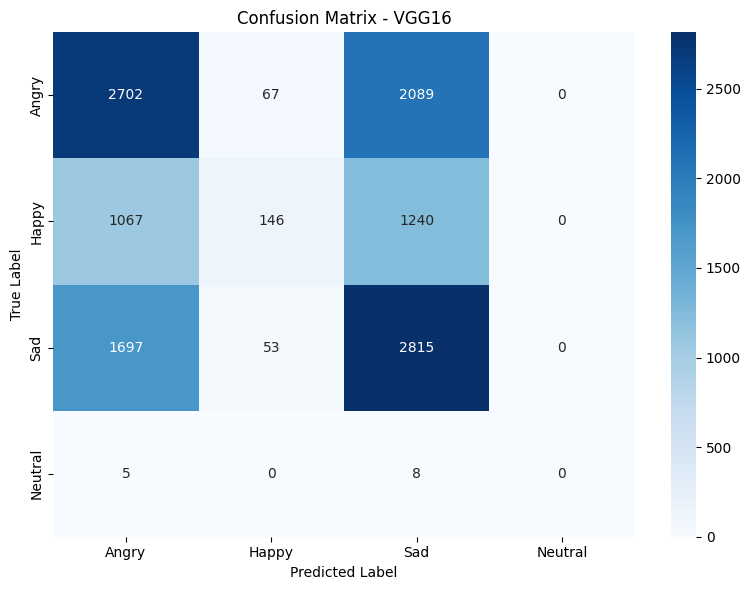


Per-class accuracy for VGG16:
   Angry: 55.62%
   Happy: 5.95%
   Sad: 61.66%
   Neutral: 0.00%

Testing VGG19
Evaluating on test set...
372/372 ━━━━━━━━━━━━━━━━━━━━ 78s 211ms/step - accuracy: 0.4549 - loss: 1.0493 - precision: 0.5531 - recall: 0.0083

📊 Results for VGG19:
   Test Loss:     1.0493
   Test Accuracy: 45.49%
   Test Precision: 0.5531
   Test Recall:    0.0083

Generating confusion matrix for VGG19...


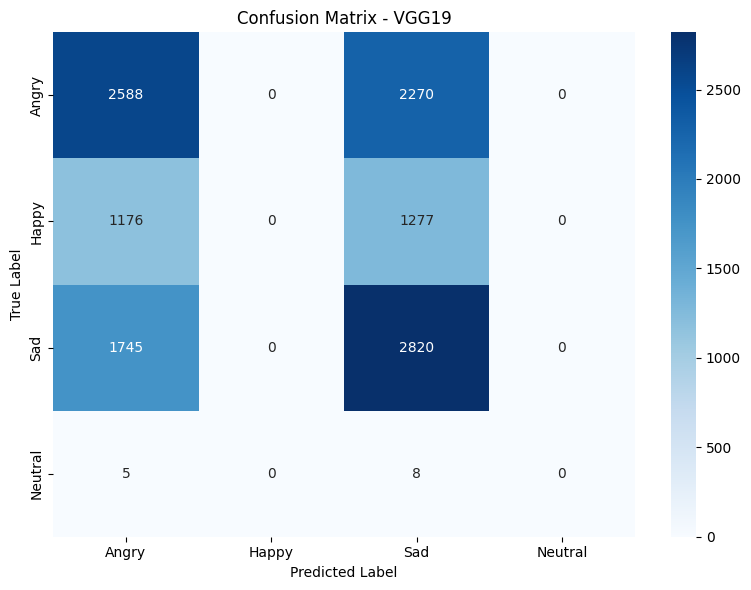


Per-class accuracy for VGG19:
   Angry: 53.27%
   Happy: 0.00%
   Sad: 61.77%
   Neutral: 0.00%

Testing ResNet50
Evaluating on test set...
372/372 ━━━━━━━━━━━━━━━━━━━━ 59s 158ms/step - accuracy: 0.4439 - loss: 1.0632 - precision: 0.5632 - recall: 0.0090

📊 Results for ResNet50:
   Test Loss:     1.0632
   Test Accuracy: 44.39%
   Test Precision: 0.5632
   Test Recall:    0.0090

Generating confusion matrix for ResNet50...


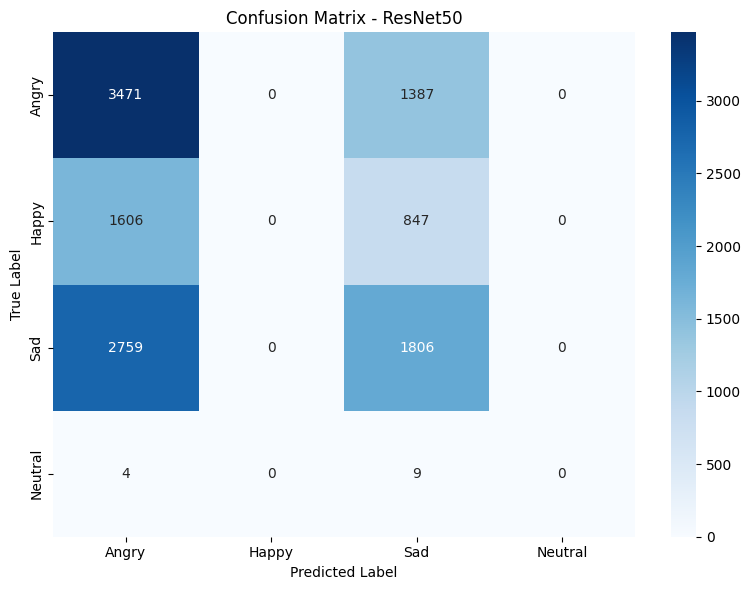


Per-class accuracy for ResNet50:
   Angry: 71.45%
   Happy: 0.00%
   Sad: 39.56%
   Neutral: 0.00%

Testing ResNet152
Evaluating on test set...
372/372 ━━━━━━━━━━━━━━━━━━━━ 137s 369ms/step - accuracy: 0.4343 - loss: 1.0638 - precision: 0.5469 - recall: 0.0118

📊 Results for ResNet152:
   Test Loss:     1.0638
   Test Accuracy: 43.43%
   Test Precision: 0.5469
   Test Recall:    0.0118

Generating confusion matrix for ResNet152...


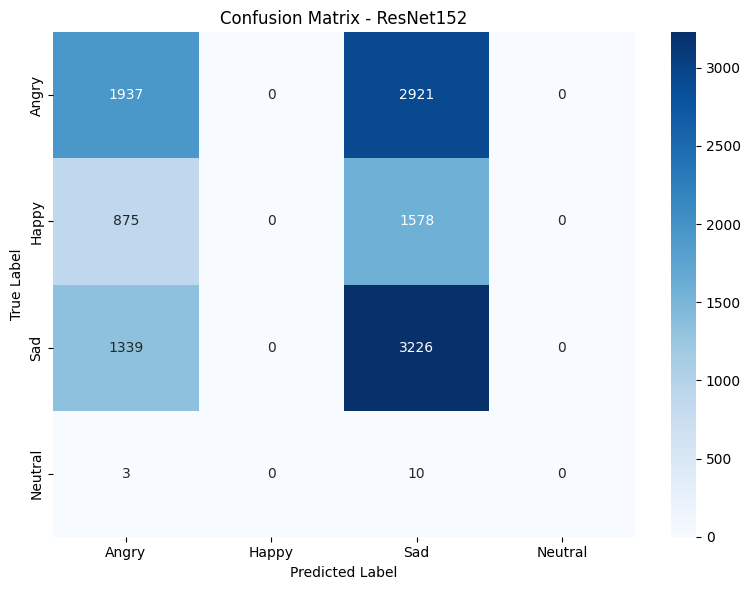


Per-class accuracy for ResNet152:
   Angry: 39.87%
   Happy: 0.00%
   Sad: 70.67%
   Neutral: 0.00%

SUMMARY - MODEL COMPARISON
Model           Accuracy     Precision    Recall       Loss        
-----------------------------------------------------------------
VGG16              47.63%       0.5828       0.0959       1.0253
VGG19              45.49%       0.5531       0.0083       1.0493
ResNet50           44.39%       0.5632       0.0090       1.0632
ResNet152          43.43%       0.5469       0.0118       1.0638

🏆 BEST MODEL: VGG16
   Accuracy:  47.63%
   Precision: 0.5828
   Recall:    0.0959
   Loss:      1.0253


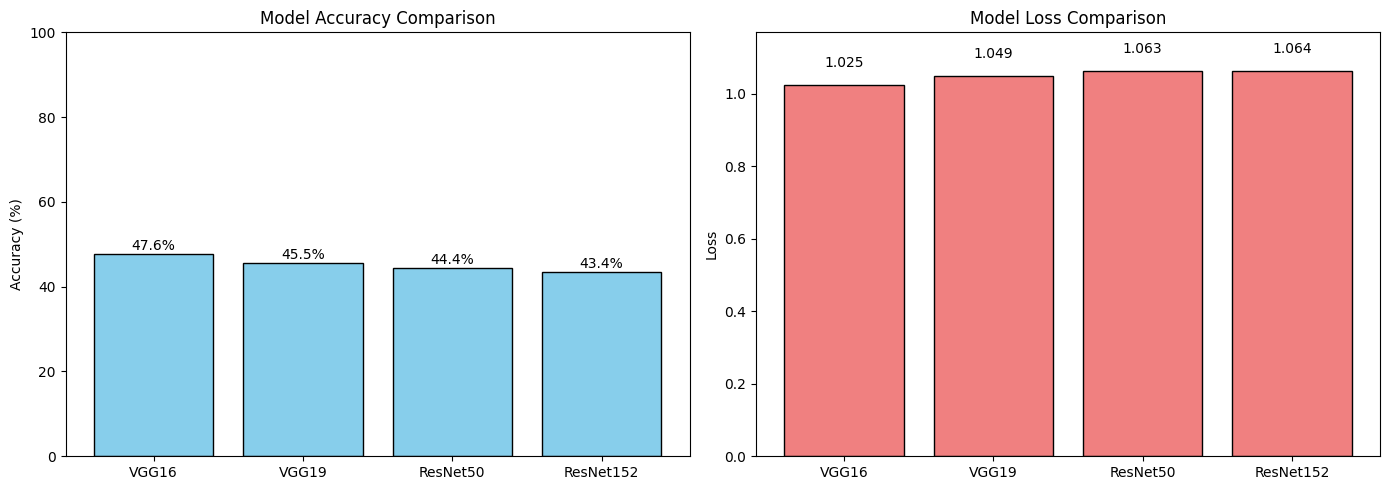


💾 Evaluation results saved to 'evaluation_results.pkl'


In [13]:
# ============================================================
# CELL 7: Evaluate All Models (CORRECTED)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("="*60)
print("EVALUATING MODELS")
print("="*60)

results = []

# Unpack models correctly - models is list of (model, model_name) tuples
for i, (model, model_name) in enumerate(models):
    print(f"\n{'='*50}")
    print(f"Testing {model_name}")
    print('='*50)
    
    # Find corresponding history
    history = None
    for hist_name, hist_data in histories:
        if hist_name == model_name:
            history = hist_data
            break
    
    # Test evaluation
    print("Evaluating on test set...")
    test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds, verbose=1)
    print(f"\n📊 Results for {model_name}:")
    print(f"   Test Loss:     {test_loss:.4f}")
    print(f"   Test Accuracy: {test_acc*100:.2f}%")
    print(f"   Test Precision: {test_prec:.4f}")
    print(f"   Test Recall:    {test_rec:.4f}")
    
    results.append({
        'model': model_name,
        'model_obj': model,
        'accuracy': test_acc,
        'precision': test_prec,
        'recall': test_rec,
        'loss': test_loss,
        'history': history
    })
    
    # Confusion matrix
    print(f"\nGenerating confusion matrix for {model_name}...")
    try:
        # Collect predictions
        y_pred_probs = []
        y_true = []
        
        for batch in test_ds:
            images, labels = batch
            preds = model.predict(images, verbose=0)
            y_pred_probs.extend(preds)
            y_true.extend(labels.numpy())
        
        y_pred_probs = np.array(y_pred_probs)
        y_true = np.array(y_true)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true_labels = np.argmax(y_true, axis=1)
        
        cm = confusion_matrix(y_true_labels, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=list(EMOTION_LABELS.values()),
                    yticklabels=list(EMOTION_LABELS.values()))
        plt.title(f'Confusion Matrix - {model_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()
        
        # Calculate per-class accuracy
        per_class_acc = cm.diagonal() / cm.sum(axis=1)
        print(f"\nPer-class accuracy for {model_name}:")
        for idx, (label, acc) in enumerate(zip(EMOTION_LABELS.values(), per_class_acc)):
            print(f"   {label}: {acc*100:.2f}%")
            
    except Exception as e:
        print(f"Could not generate confusion matrix: {e}")

# Summary comparison
print("\n" + "="*60)
print("SUMMARY - MODEL COMPARISON")
print("="*60)
print(f"{'Model':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'Loss':<12}")
print("-"*65)
for r in results:
    print(f"{r['model']:<15} {r['accuracy']*100:>8.2f}%     {r['precision']:>8.4f}     {r['recall']:>8.4f}     {r['loss']:>8.4f}")

# Best model
best_idx = np.argmax([r['accuracy'] for r in results])
best_result = results[best_idx]
print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_result['model']}")
print(f"   Accuracy:  {best_result['accuracy']*100:.2f}%")
print(f"   Precision: {best_result['precision']:.4f}")
print(f"   Recall:    {best_result['recall']:.4f}")
print(f"   Loss:      {best_result['loss']:.4f}")
print("="*60)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models_names = [r['model'] for r in results]
accuracies = [r['accuracy']*100 for r in results]
axes[0].bar(models_names, accuracies, color='skyblue', edgecolor='black')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([0, 100])
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 1, f'{acc:.1f}%', ha='center')

# Loss comparison
losses = [r['loss'] for r in results]
axes[1].bar(models_names, losses, color='lightcoral', edgecolor='black')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss Comparison')
axes[1].set_ylim([0, max(losses) * 1.1])
for i, loss in enumerate(losses):
    axes[1].text(i, loss + 0.05, f'{loss:.3f}', ha='center')

plt.tight_layout()
plt.show()

# Save results
import pickle
with open('evaluation_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("\n💾 Evaluation results saved to 'evaluation_results.pkl'")

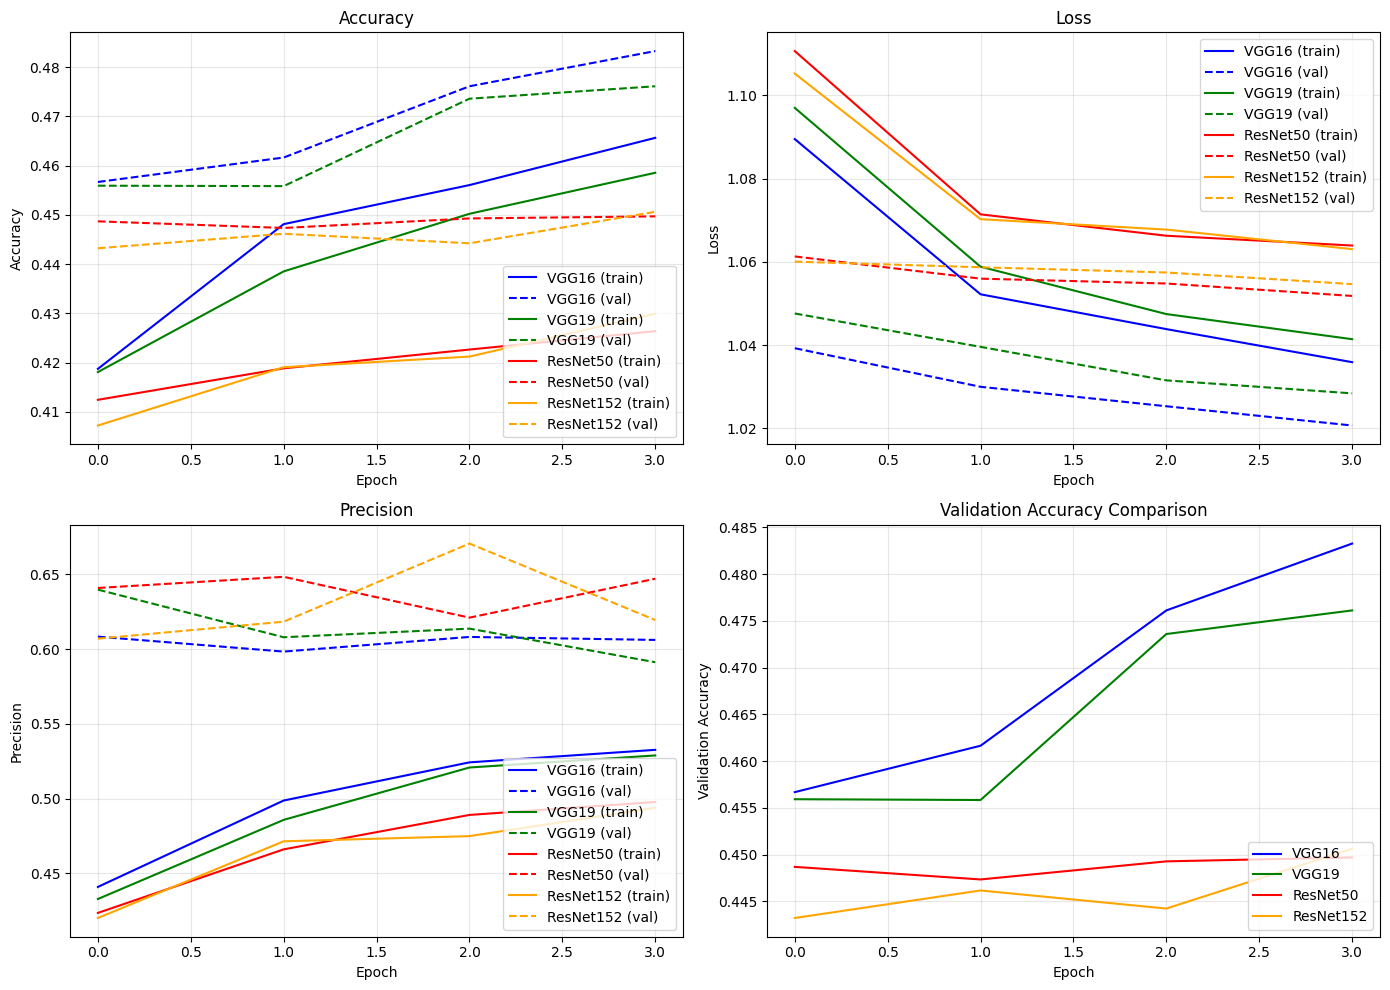

In [14]:
# ============================================================
# CELL 8: Plot Training History
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['blue', 'green', 'red', 'orange']

for i, result in enumerate(results):
    history = result['history']
    name = result['model']
    color = colors[i % len(colors)]
    
    axes[0].plot(history.history['accuracy'], color=color, label=f'{name} (train)')
    axes[0].plot(history.history['val_accuracy'], '--', color=color, label=f'{name} (val)')
    
    axes[1].plot(history.history['loss'], color=color, label=f'{name} (train)')
    axes[1].plot(history.history['val_loss'], '--', color=color, label=f'{name} (val)')
    
    axes[2].plot(history.history['precision'], color=color, label=f'{name} (train)')
    axes[2].plot(history.history['val_precision'], '--', color=color, label=f'{name} (val)')
    
    axes[3].plot(history.history['val_accuracy'], color=color, label=name)

axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].set_title('Precision')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

axes[3].set_title('Validation Accuracy Comparison')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Validation Accuracy')
axes[3].legend(loc='lower right')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

BEST MODEL SELECTION
Best Model: VGG16
Test Accuracy: 47.63%
Test Precision: 0.5828
Test Recall: 0.0959
Test Loss: 1.0253

⚠️ No convolutional layer found in the model

✅ Best model saved as 'best_emotion_model.keras'

TESTING BEST MODEL ON RANDOM SAMPLES


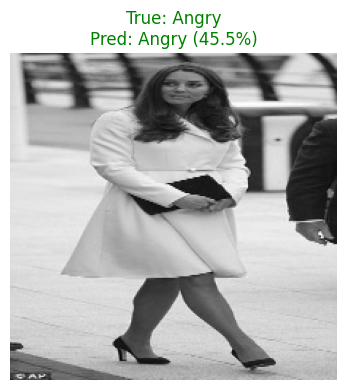

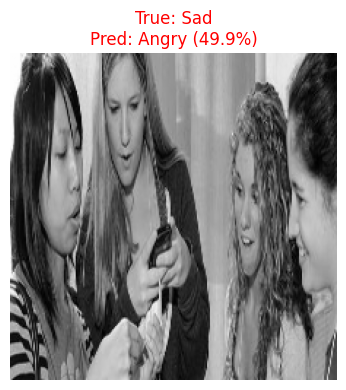

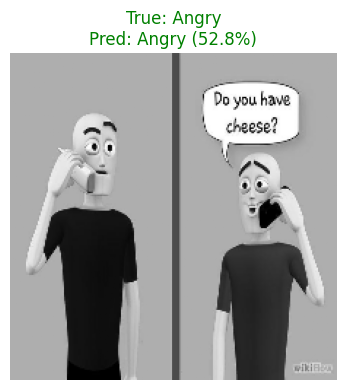

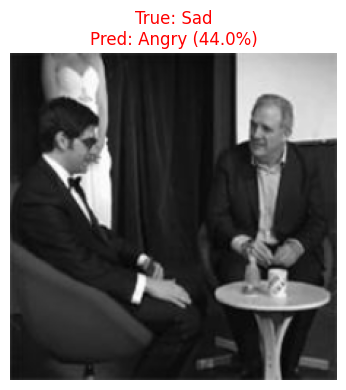

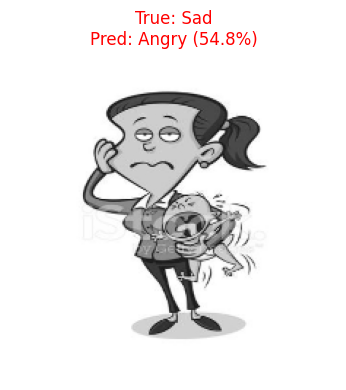


TRAINING HISTORY FOR BEST MODEL


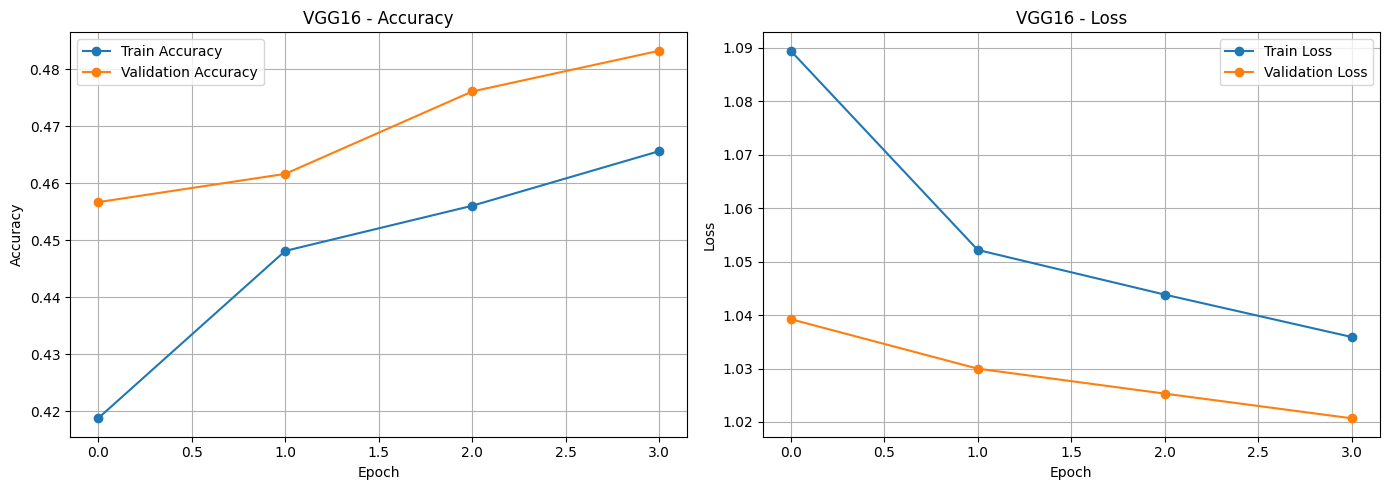


📊 Training Summary for VGG16:
   Best Validation Accuracy: 0.4833 (Epoch 4)
   Best Validation Loss: 1.0207
   Final Training Accuracy: 0.4656
   Final Validation Accuracy: 0.4833

✅ All cells completed successfully!


In [17]:
# ============================================================
# CELL 10: Best Model Selection & Test Samples (CORRECTED)
# ============================================================
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Find best model by test accuracy
best_idx = np.argmax([r['accuracy'] for r in results])
best_model_info = models[best_idx]  # This is a tuple (model, model_name)
best_result = results[best_idx]

# Extract model and name from the tuple
if isinstance(best_model_info, tuple):
    best_model = best_model_info[0]  # The actual model object
    best_model_name = best_model_info[1]  # The model name
else:
    best_model = best_model_info
    best_model_name = best_result['model']

print("="*60)
print("BEST MODEL SELECTION")
print("="*60)
print(f"Best Model: {best_result['model']}")
print(f"Test Accuracy: {best_result['accuracy']*100:.2f}%")
print(f"Test Precision: {best_result['precision']:.4f}")
print(f"Test Recall: {best_result['recall']:.4f}")
print(f"Test Loss: {best_result['loss']:.4f}")

# Find last convolutional layer for Grad-CAM
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

try:
    last_conv = find_last_conv_layer(best_model)
    if last_conv:
        print(f"\nLast convolutional layer: {last_conv}")
    else:
        print("\n⚠️ No convolutional layer found in the model")
except Exception as e:
    print(f"\n⚠️ Could not find conv layer: {e}")

# Save best model
try:
    best_model.save('best_emotion_model.keras')
    print("\n✅ Best model saved as 'best_emotion_model.keras'")
except Exception as e:
    print(f"\n⚠️ Could not save model: {e}")

# Test on random samples from test set
print("\n" + "="*60)
print("TESTING BEST MODEL ON RANDOM SAMPLES")
print("="*60)

# Load a few test images for visualization
num_samples = 5
test_indices = np.random.choice(len(test_paths), min(num_samples, len(test_paths)), replace=False)

for idx in test_indices:
    try:
        # Load and preprocess image
        img_path = test_paths[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"⚠️ Could not load image: {img_path}")
            continue
            
        img = cv2.resize(img, (224, 224))
        img = np.stack([img] * 3, axis=-1).astype('float32') / 255.0
        img = np.expand_dims(img, axis=0)
        
        # Get true label
        true_label = np.argmax(y_test[idx])
        
        # Predict
        pred = best_model.predict(img, verbose=0)
        pred_label = np.argmax(pred)
        confidence = pred[0][pred_label]
        
        # Display
        plt.figure(figsize=(4, 4))
        plt.imshow(img[0])
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"True: {EMOTION_LABELS[true_label]}\nPred: {EMOTION_LABELS[pred_label]} ({confidence:.1%})", color=color)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"⚠️ Error processing sample {idx}: {e}")

# Also show training history for best model
if best_result['history'] is not None:
    print("\n" + "="*60)
    print("TRAINING HISTORY FOR BEST MODEL")
    print("="*60)
    
    history = best_result['history']
    
    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    axes[0].set_title(f'{best_model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
    axes[1].set_title(f'{best_model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print best metrics
    best_val_acc = max(history.history['val_accuracy'])
    best_val_acc_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
    best_val_loss = min(history.history['val_loss'])
    
    print(f"\n📊 Training Summary for {best_model_name}:")
    print(f"   Best Validation Accuracy: {best_val_acc:.4f} (Epoch {best_val_acc_epoch})")
    print(f"   Best Validation Loss: {best_val_loss:.4f}")
    print(f"   Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"   Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

print("\n✅ All cells completed successfully!")


TESTING CHILD-FRIENDLY EXPLANATIONS


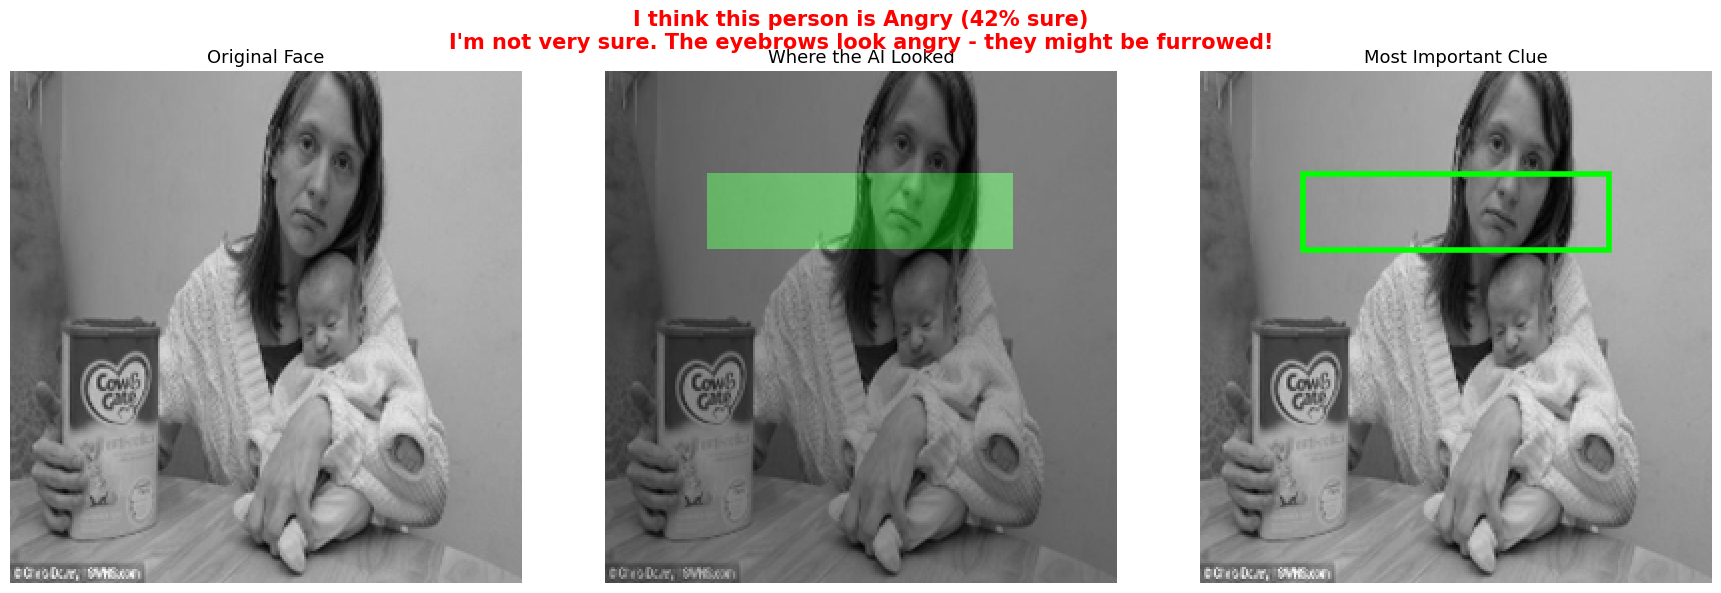


🧠 AI Explanation
Prediction: Angry
Confidence: 42%
Reason: The eyebrows look angry - they might be furrowed!
Confidence level: I'm not very sure.


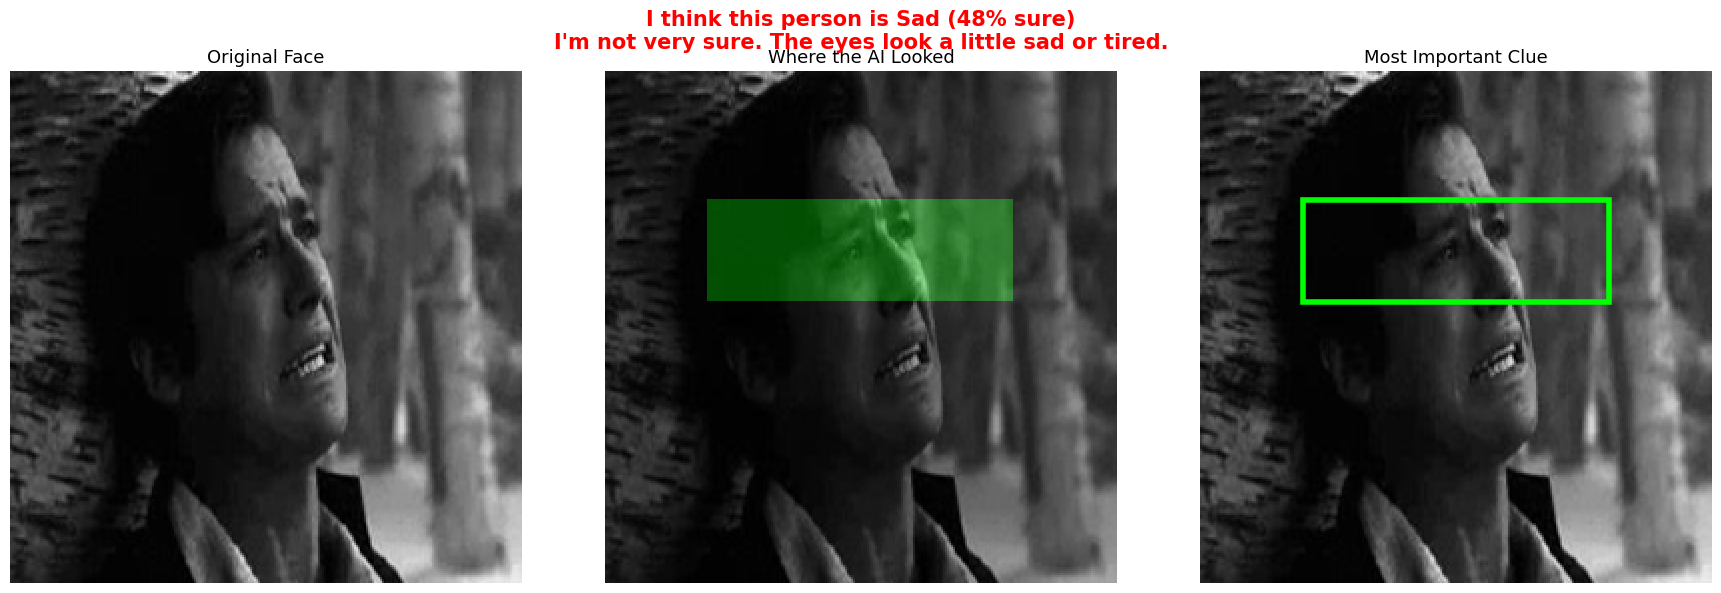


🧠 AI Explanation
Prediction: Sad
Confidence: 48%
Reason: The eyes look a little sad or tired.
Confidence level: I'm not very sure.


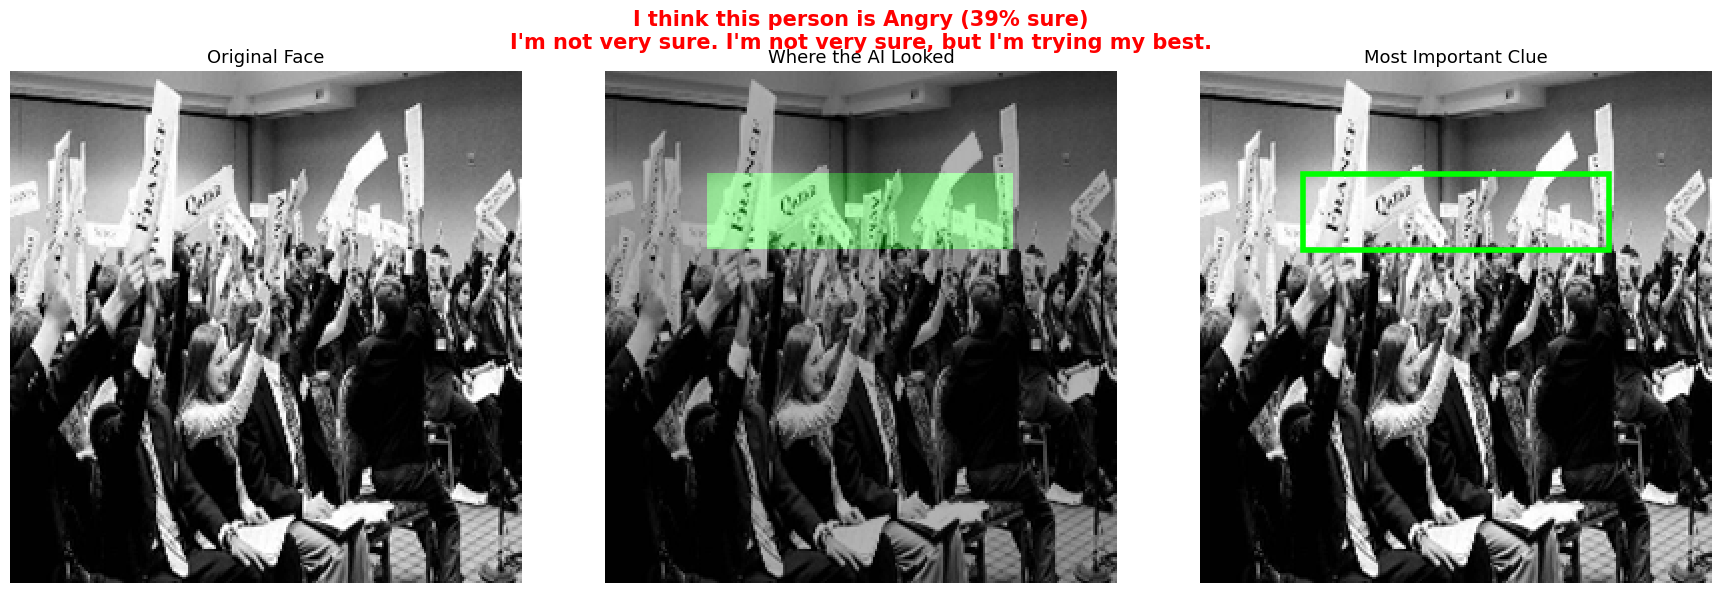


🧠 AI Explanation
Prediction: Angry
Confidence: 39%
Reason: I'm not very sure, but I'm trying my best.
Confidence level: I'm not very sure.

✅ All done! Child-friendly explanation module is working!


In [22]:
# ============================================================
# CELL 12: SIMPLE CHILD-FRIENDLY EXPLANATION MODULE (NO GRAD-CAM)
# ============================================================
import matplotlib.patches as patches
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define facial regions for explanation
FACE_REGIONS = {
    "Eyes": (0.25, 0.45, 0.20, 0.80),
    "Eyebrows": (0.20, 0.35, 0.20, 0.80),
    "Mouth": (0.60, 0.85, 0.25, 0.75),
    "Nose": (0.45, 0.60, 0.35, 0.65),
    "Whole Face": (0.10, 0.90, 0.10, 0.90)
}

# Child-friendly explanations
FRIENDLY_EXPLANATIONS = {
    ("Happy", "Mouth"): "I see a big smile! Happy people usually smile a lot.",
    ("Happy", "Eyes"): "Your eyes look bright and happy!",
    ("Sad", "Mouth"): "The mouth looks a bit down or frowning.",
    ("Sad", "Eyes"): "The eyes look a little sad or tired.",
    ("Angry", "Eyebrows"): "The eyebrows look angry - they might be furrowed!",
    ("Angry", "Mouth"): "The mouth looks tight or frowning, which can mean anger.",
    ("Neutral", "Whole Face"): "The face looks calm and relaxed, not showing strong feelings.",
    ("Neutral", "Mouth"): "The mouth is in a relaxed, neutral position.",
}

# Simple rule-based region importance (since Grad-CAM is having issues)
def get_simple_region_prediction(pred_emotion):
    """Return likely important region based on emotion."""
    region_map = {
        "Happy": "Mouth",
        "Sad": "Eyes", 
        "Angry": "Eyebrows",
        "Neutral": "Whole Face"
    }
    return region_map.get(pred_emotion, "Whole Face")

def generate_child_friendly_reason(pred_emotion, region, confidence):
    """Return a simple, child‑friendly explanation."""
    if confidence < 0.4:
        return "I'm not very sure, but I'm trying my best."
    key = (pred_emotion, region)
    if key in FRIENDLY_EXPLANATIONS:
        return FRIENDLY_EXPLANATIONS[key]
    return f"I noticed something important in the {region.lower()}."

def explain_prediction_child_friendly(image_array, model):
    """Generate and display a child‑friendly explanation for a single image."""
    # Ensure correct input shape (224, 224, 3)
    if len(image_array.shape) == 2:
        image_array = np.stack([image_array] * 3, axis=-1)
    elif image_array.shape[-1] == 1:
        image_array = np.squeeze(image_array, axis=-1)
        image_array = np.stack([image_array] * 3, axis=-1)
    
    # Ensure values are in [0, 1]
    if image_array.max() > 1:
        image_array = image_array / 255.0
    
    img_array = np.expand_dims(image_array, axis=0)

    # Prediction
    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_emotion = EMOTION_LABELS[pred_idx]
    confidence = float(pred_probs[pred_idx])
    
    # Get important region based on emotion
    important_region = get_simple_region_prediction(pred_emotion)
    reason = generate_child_friendly_reason(pred_emotion, important_region, confidence)

    # Prepare images for display
    DISPLAY_SIZE = 256
    img_display = (image_array * 255).astype(np.uint8)
    img_display = cv2.resize(img_display, (DISPLAY_SIZE, DISPLAY_SIZE),
                              interpolation=cv2.INTER_CUBIC)

    # Create a simple heatmap-like overlay (simulated)
    overlay = img_display.copy()
    
    # Highlight the important region
    if important_region:
        y1, y2, x1, x2 = FACE_REGIONS[important_region]
        y1_px, y2_px = int(y1 * DISPLAY_SIZE), int(y2 * DISPLAY_SIZE)
        x1_px, x2_px = int(x1 * DISPLAY_SIZE), int(x2 * DISPLAY_SIZE)
        
        # Create a heatmap effect for the important region
        heatmap_overlay = np.zeros((DISPLAY_SIZE, DISPLAY_SIZE, 3), dtype=np.uint8)
        heatmap_overlay[y1_px:y2_px, x1_px:x2_px] = [0, 255, 0]  # Green highlight
        overlay = cv2.addWeighted(img_display, 0.7, heatmap_overlay, 0.3, 0)

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_display)
    axes[0].set_title("Original Face", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title("Where the AI Looked", fontsize=13)
    axes[1].axis("off")

    axes[2].imshow(img_display)
    if important_region:
        y1, y2, x1, x2 = FACE_REGIONS[important_region]
        y1_px, y2_px = int(y1 * DISPLAY_SIZE), int(y2 * DISPLAY_SIZE)
        x1_px, x2_px = int(x1 * DISPLAY_SIZE), int(x2 * DISPLAY_SIZE)
        rect = patches.Rectangle((x1_px, y1_px), x2_px - x1_px, y2_px - y1_px,
                                 linewidth=4, edgecolor="lime", facecolor="none")
        axes[2].add_patch(rect)
    axes[2].set_title("Most Important Clue", fontsize=13)
    axes[2].axis("off")

    # Confidence tone
    if confidence > 0.75:
        certainty = "I am very sure!"
    elif confidence > 0.5:
        certainty = "I think so."
    else:
        certainty = "I'm not very sure."

    # Get confidence color
    if confidence > 0.7:
        conf_color = 'green'
    elif confidence > 0.5:
        conf_color = 'orange'
    else:
        conf_color = 'red'

    plt.suptitle(
        f"I think this person is {pred_emotion} ({confidence:.0%} sure)\n"
        f"{certainty} {reason}",
        fontsize=15, fontweight="bold", color=conf_color
    )
    plt.tight_layout()
    plt.show()

    print("\n🧠 AI Explanation")
    print(f"Prediction: {pred_emotion}")
    print(f"Confidence: {confidence:.0%}")
    print(f"Reason: {reason}")
    print(f"Confidence level: {certainty}")

# Test on random samples from test set
print("\n" + "="*60)
print("TESTING CHILD-FRIENDLY EXPLANATIONS")
print("="*60)

num_examples = 3
test_indices = np.random.choice(len(test_paths), min(num_examples, len(test_paths)), replace=False)

for idx in test_indices:
    try:
        # Load and preprocess the image
        img_path = test_paths[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"⚠️ Could not load image: {img_path}")
            continue
            
        img = cv2.resize(img, (224, 224))
        img = img.astype('float32') / 255.0
        
        # Show the image and explanation
        explain_prediction_child_friendly(img, best_model)
        
    except Exception as e:
        print(f"⚠️ Error processing image {idx}: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("✅ All done! Child-friendly explanation module is working!")
print("="*60)